In [1]:
!pip install ultralytics opencv-python matplotlib pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.2 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import os
import yaml
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!unzip -o combined.v1i.yolov8.zip

Streaming output truncated to the last 5000 lines.
 extracting: train/images/204352342_jpg.rf.f2de665e879c6603c44d08c8bf008ce3.jpg  
 extracting: train/images/95054992_jpg.rf.5c0a8a8294059fa87026819f774fd2b5.jpg  
 extracting: train/images/205167300_jpg.rf.613fc556c271c5bad1de408de2b38472.jpg  
 extracting: train/images/175533881_jpeg.rf.3cc0a4d5e7ee99362512f73b8cfe5fe4.jpg  
 extracting: train/images/59285706_jpg.rf.c7fc5b4eb4e0ae4093107f9c49721737.jpg  
 extracting: train/images/127183558_jpg.rf.6ef54756751553c3bf29ac909c893ef6.jpg  
 extracting: train/images/121622054_jpeg.rf.4db5bee5ab334289fcd501dcc8d35f9c.jpg  
 extracting: train/images/117078972_jpeg.rf.73e8bb034c5a53ec75855ae3d0e2bcf9.jpg  
 extracting: train/images/54518868_jpg.rf.aac55da4eae4b5ebe88255d4ebbb0716.jpg  
 extracting: train/images/54590922_jpeg.rf.f9748b9352637cf965c898dedfa69ba3.jpg  
 extracting: train/images/173701904_jpg.rf.1dee18aebd82cad798f245c030678697.jpg  
 extracting: valid/images/52329334_jpeg.rf.8cbd

In [4]:
model = YOLO("yolov8n.pt")

In [5]:
results = model.train(
  data="/content/data.yaml",
  epochs=100,
  imgsz=512,
  batch=16
 )

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, opti

In [6]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1106.8±646.5 MB/s, size: 49.0 KB)
val: Scanning /content/valid/labels.cache... 392 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 392/392 117.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.9it/s 5.1s
                   all        392       1114      0.777      0.713      0.782      0.468
            Budgerigar        265        803      0.757      0.644      0.743      0.436
             Cockatiel        127        311      0.797      0.781      0.821      0.499
Speed: 1.8ms preprocess, 3.7ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.


image 1/1 /content/sunfyre.jpg: 512x288 1 Cockatiel, 7.0ms
Speed: 1.9ms preprocess, 7.0ms inference, 1.7ms postprocess per image at shape (1, 3, 512, 288)


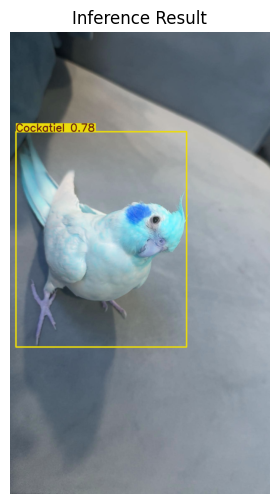

In [9]:
sunfyre = model('/content/sunfyre.jpg')

annotated = sunfyre[0].plot()
plt.figure(figsize=(10, 6))
plt.imshow(annotated)
plt.axis("off")
plt.title("Inference Result")
plt.show()


image 1/1 /content/fr.png: 512x352 1 Budgerigar, 47.3ms
Speed: 2.4ms preprocess, 47.3ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 352)


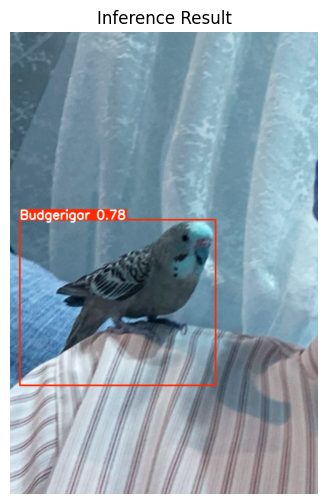

In [12]:
fr = model('/content/fr.png')

annotated = fr[0].plot()
plt.figure(figsize=(10, 6))
plt.imshow(annotated)
plt.axis("off")
plt.title("Inference Result")
plt.show()